# Knowing data

In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [68]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [69]:
raw_url="https://gist.githubusercontent.com/anu-006/8ee05be0720e06ea7bc55002f56fb409/raw/82db807b5287a09283a9d64ba4db09c248643afc/taxi_trip_pricing.csv"

In [70]:
data=pd.read_csv(raw_url)

In [71]:
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [72]:
data.shape

(1000, 11)

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


# Checking missing values


In [74]:
(data.isnull().sum()/len(data))*100

,0
Trip_Distance_km,5.0
Time_of_Day,5.0
Day_of_Week,5.0
Passenger_Count,5.0
Traffic_Conditions,5.0
Weather,5.0
Base_Fare,5.0
Per_Km_Rate,5.0
Per_Minute_Rate,5.0
Trip_Duration_Minutes,5.0


In [75]:
data.duplicated().sum()

np.int64(0)

In [76]:
data.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [77]:
corr=data.corr(numeric_only=True)

<Axes: >

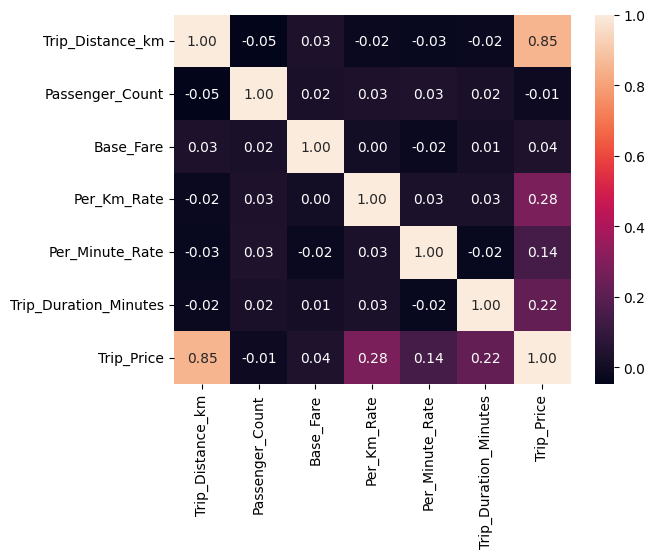

In [78]:
sns.heatmap(corr,annot=True,fmt='.2f')

In [79]:
data.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [80]:
num=['Trip_Distance_km','Passenger_Count','Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']

In [81]:
cat=['Time_of_Day', 'Day_of_Week','Traffic_Conditions', 'Weather']

In [82]:
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


# Graphs

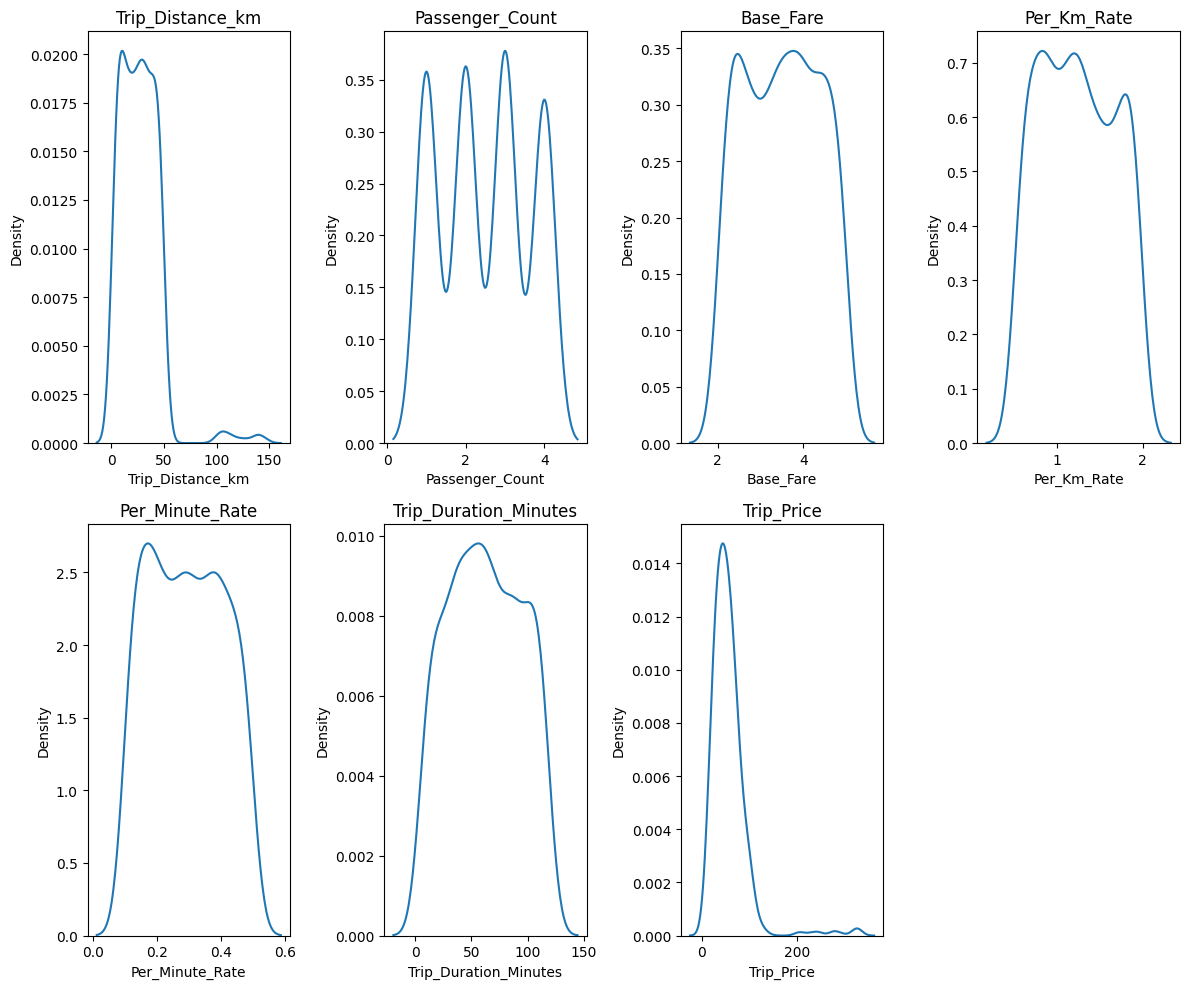

In [83]:
plt.figure(figsize=(12,10))

for index,col in enumerate(num):

  plt.subplot(2,4,index+1)
  sns.kdeplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()


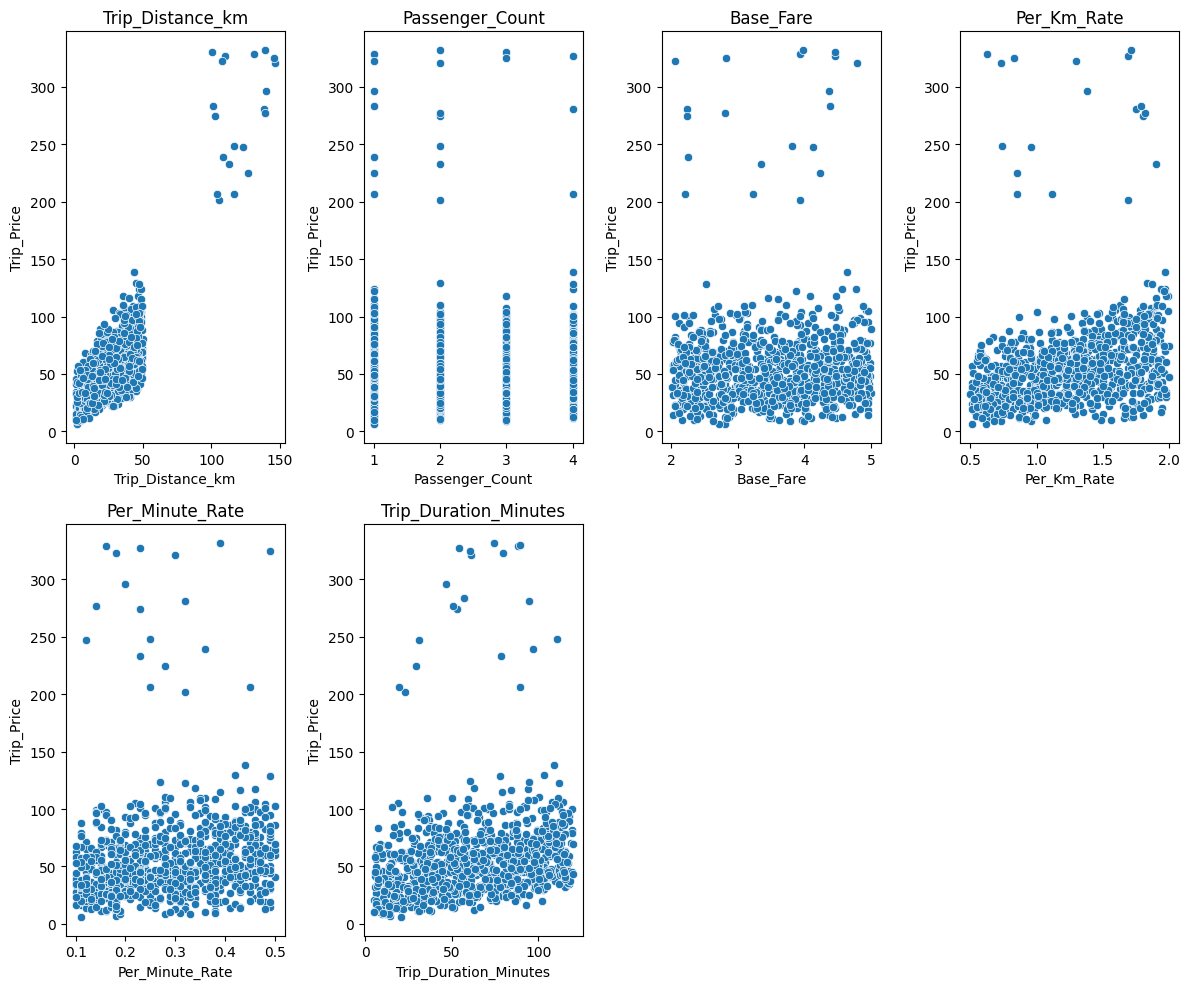

In [84]:
plt.figure(figsize=(12,10))

features_for_scatter = [col for col in num if col != 'Trip_Price']

for index,col in enumerate(features_for_scatter):

  plt.subplot(2,4,index+1)
  sns.scatterplot(x=data[col],y=data['Trip_Price'])
  plt.title(col)
  plt.tight_layout()
plt.show()

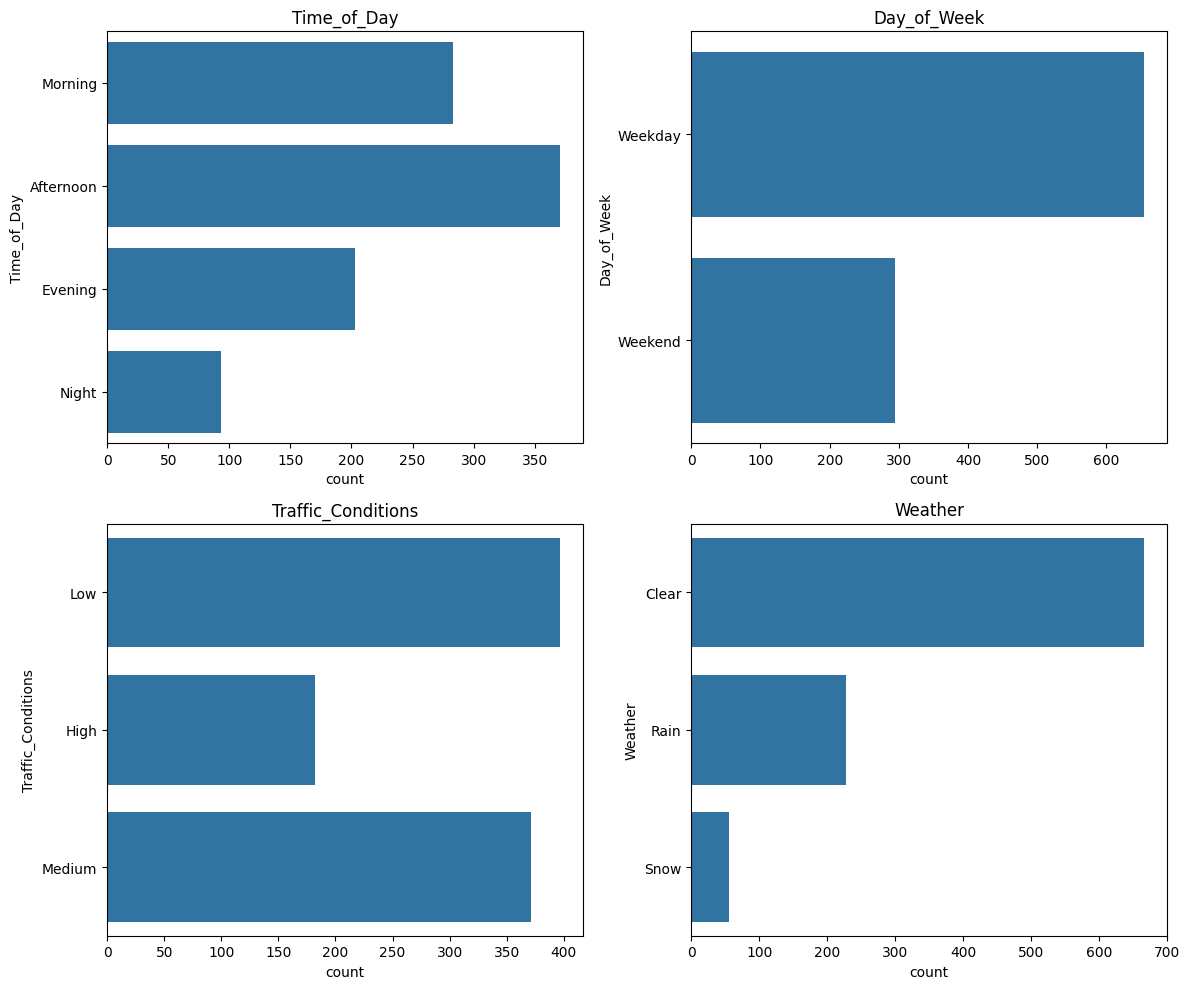

In [85]:
plt.figure(figsize=(12,10))

for index,col in enumerate(cat):

  plt.subplot(2,2,index+1)
  sns.countplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

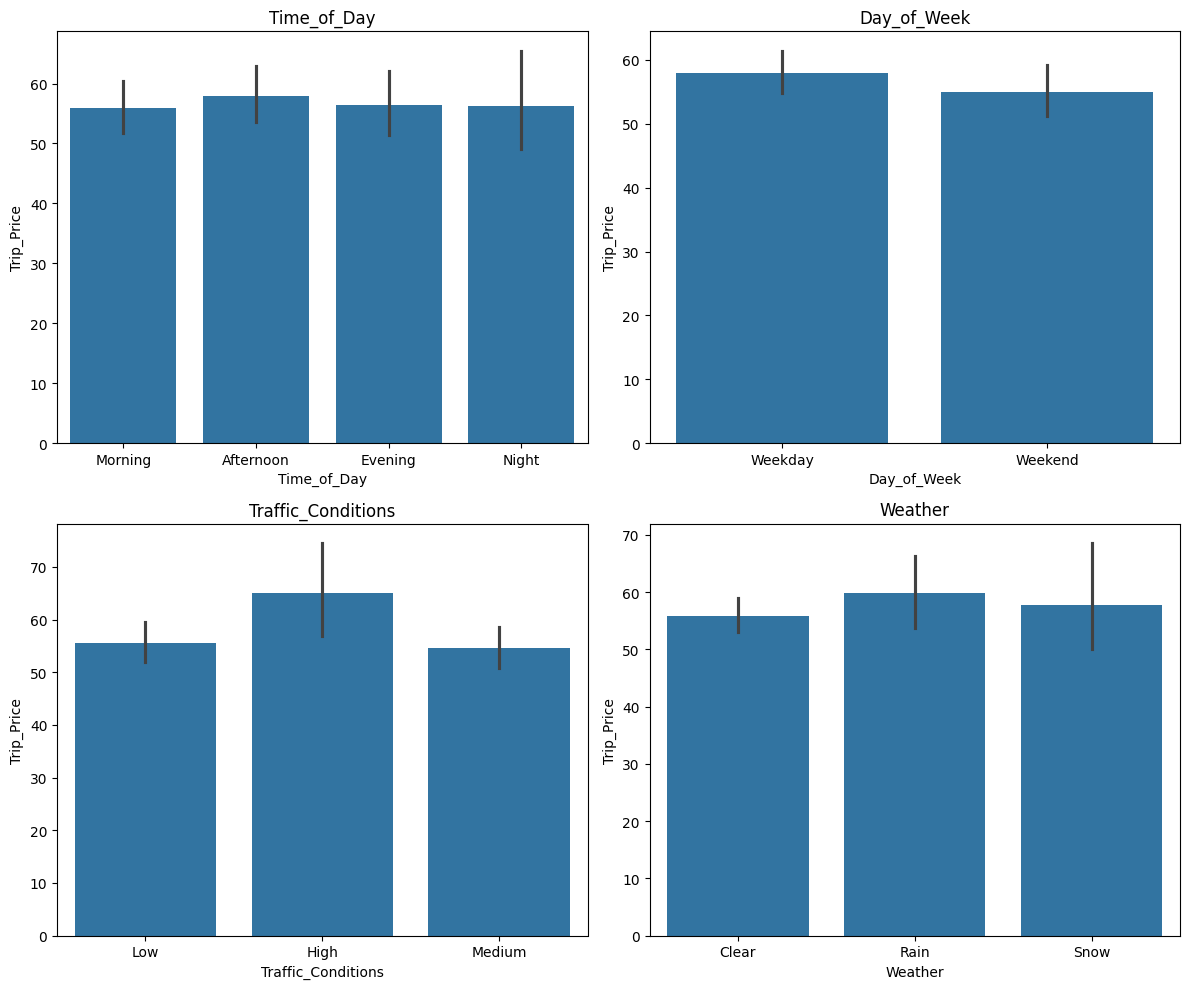

In [86]:
plt.figure(figsize=(12,10))

for index,col in enumerate(cat):

  plt.subplot(2,2,index+1)
  sns.barplot(x=data[col],y=data['Trip_Price'])
  plt.title(col)
  plt.tight_layout()
plt.show()

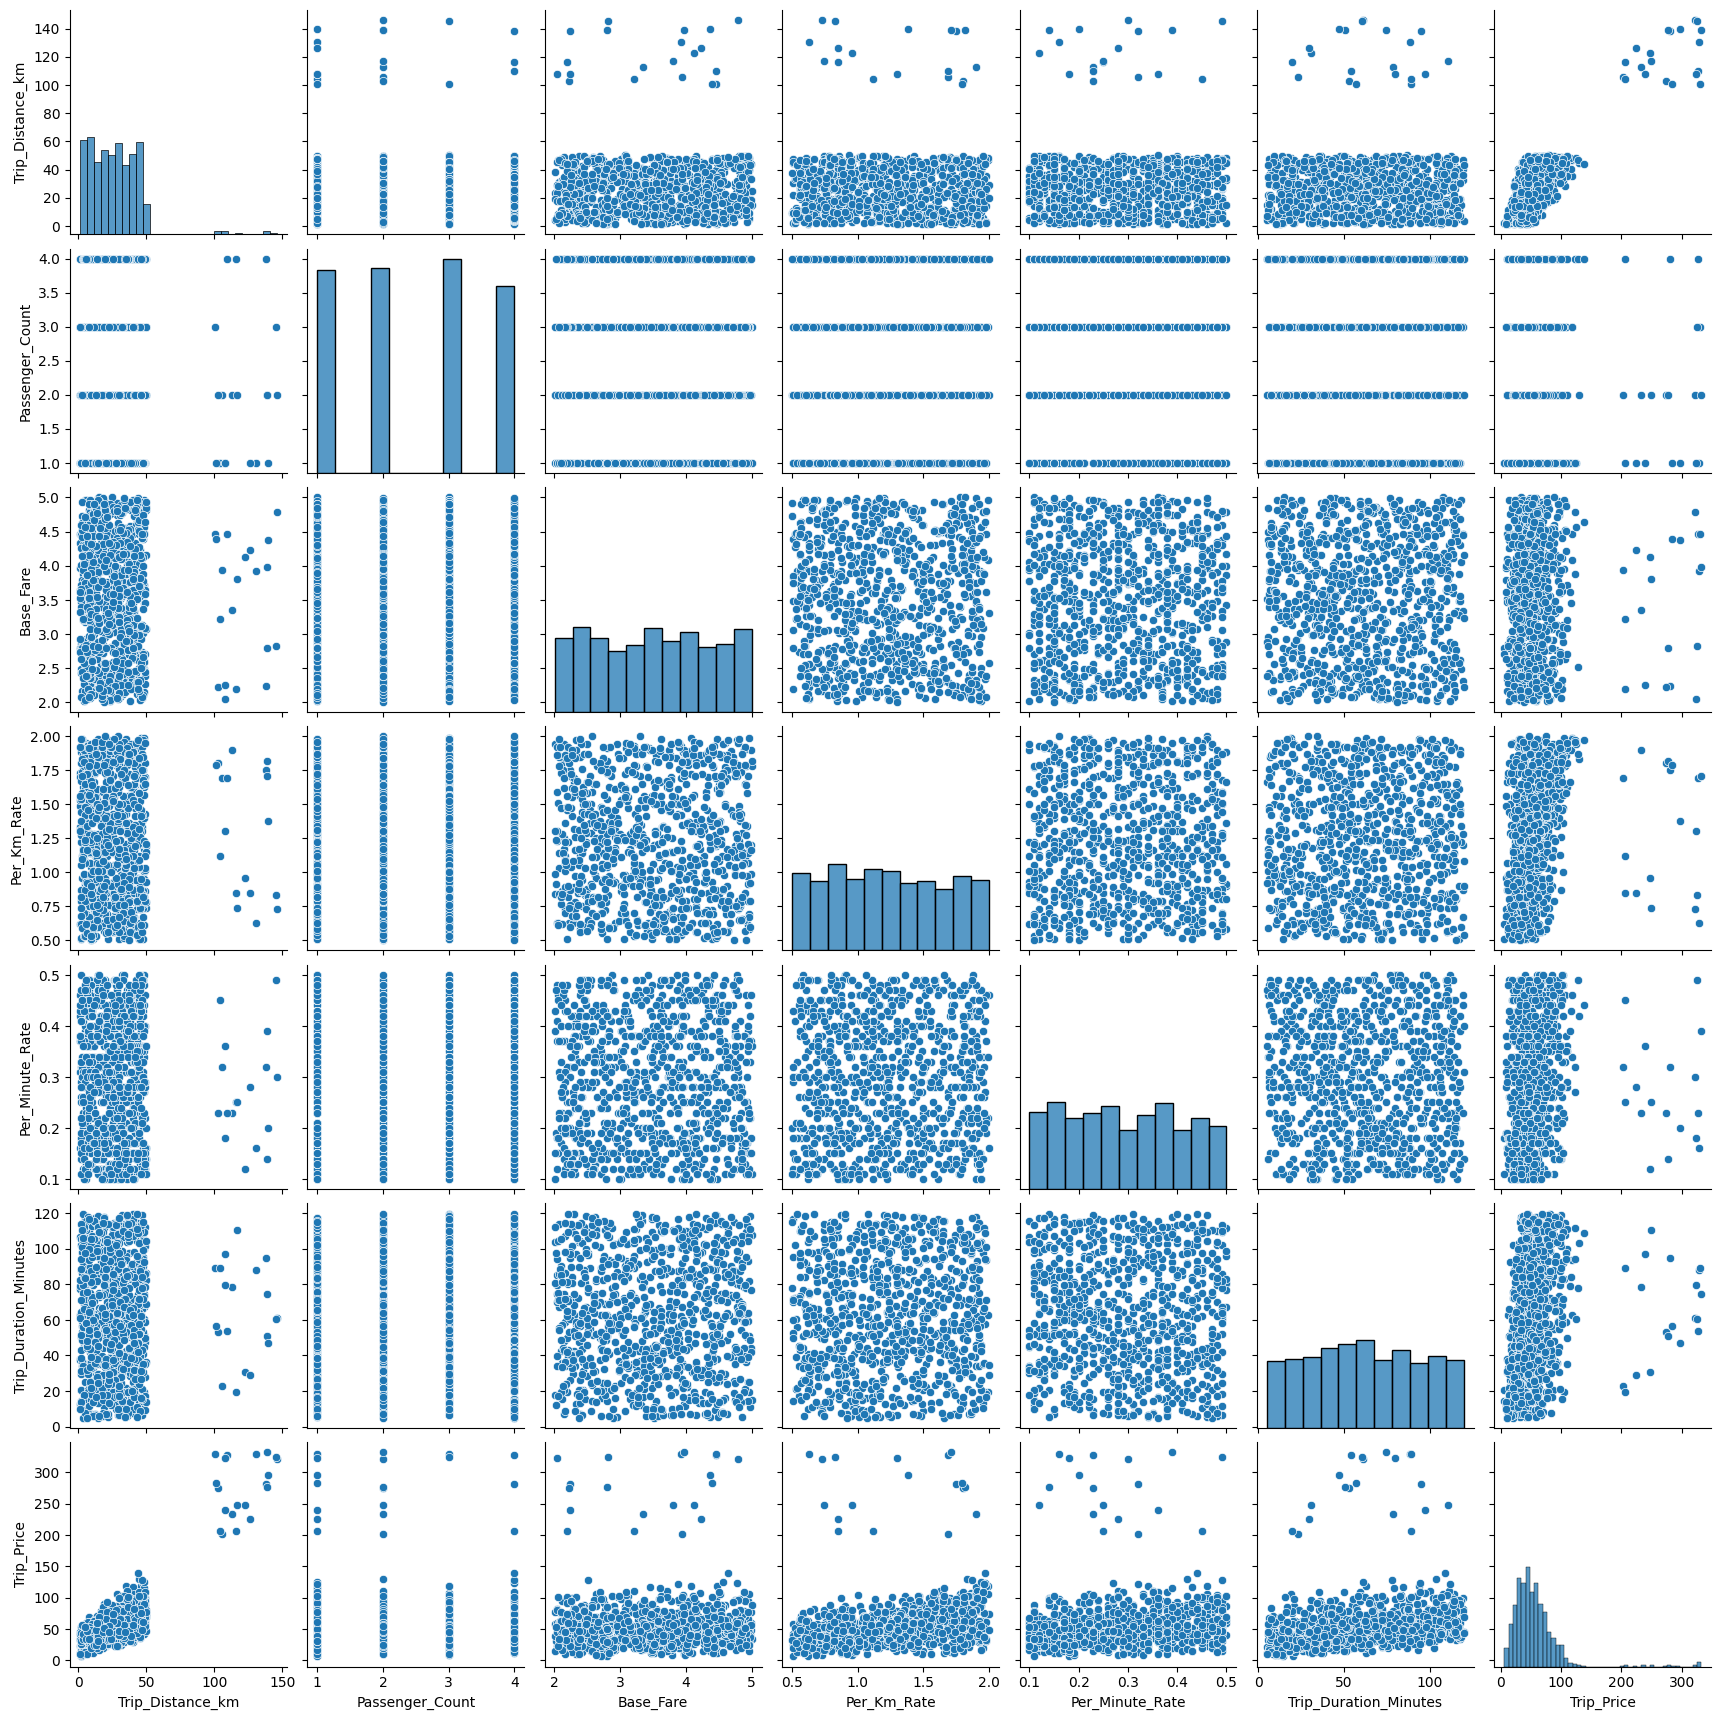

In [87]:
sns.pairplot(data[num])

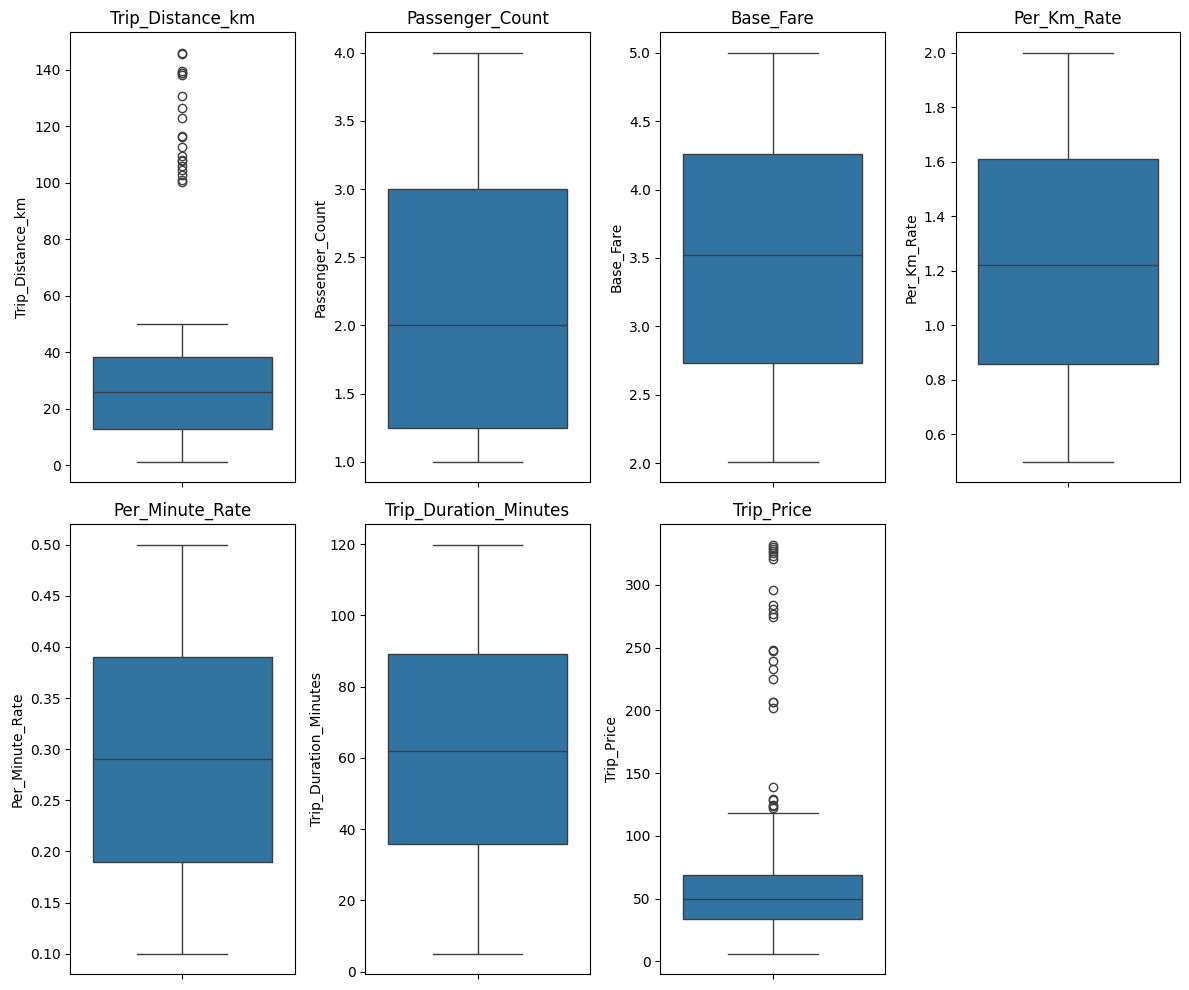

In [88]:
plt.figure(figsize=(12,10))

for index,col in enumerate(num):

  plt.subplot(2,4,index+1)
  sns.boxplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

In [89]:
Q1 = data['Trip_Price'].quantile(0.25)
Q3 = data['Trip_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

data['Trip_Price'] = np.where(
    data['Trip_Price'] < lower_limit,
    lower_limit,
    np.where(
        data['Trip_Price'] > upper_limit,
        upper_limit,
        data['Trip_Price']
    )
)

In [90]:
for i in num:
  print(f'{i} : ',data[i].skew())

Trip_Distance_km :  2.2360100179977933
Passenger_Count :  0.01625467599242435
Base_Fare :  -0.0051492734272576765
Per_Km_Rate :  0.0792064285660391
Per_Minute_Rate :  0.05869506542779452
Trip_Duration_Minutes :  0.01774912926217117
Trip_Price :  0.6582320043302972


### Data Preprocessing and Model Training

In [91]:
numerical_features = [col for col in num if col != 'Trip_Price']
categorical_features = cat

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Drop rows where 'Trip_Price' is NaN, as the target variable cannot have missing values
data_cleaned = data.dropna(subset=['Trip_Price'])

# Define features (X) and target (y)
X = data_cleaned.drop('Trip_Price', axis=1)
y = data_cleaned['Trip_Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [92]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

# Create and train pipelines for each model
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])


    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Evaluate the model
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {'MAE': mae, 'MSE': mse, 'R2': r2}

    print(f"--- {name} ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"R-squared (R2): {r2:.4f}\n")

# Display all results in a DataFrame for comparison
results_df = pd.DataFrame(results).T
display(results_df)

--- Linear Regression ---
Mean Absolute Error (MAE): 7.8415
Mean Squared Error (MSE): 131.6986
R-squared (R2): 0.8049

--- Decision Tree Regressor ---
Mean Absolute Error (MAE): 8.6313
Mean Squared Error (MSE): 131.9732
R-squared (R2): 0.8045

--- Random Forest Regressor ---
Mean Absolute Error (MAE): 5.0629
Mean Squared Error (MSE): 49.0104
R-squared (R2): 0.9274

--- XGBoost Regressor ---
Mean Absolute Error (MAE): 5.1056
Mean Squared Error (MSE): 51.4819
R-squared (R2): 0.9237



,MAE,MSE,R2
Linear Regression,7.841470,131.698631,0.804938
Decision Tree Regressor,8.631301,131.973231,0.804531
Random Forest Regressor,5.062880,49.010399,0.927410
XGBoost Regressor,5.105624,51.481934,0.923749


XGBoost regressor has higher r2_score of 0.93